In [7]:
import sys
sys.path.append("..")  # jika notebook dijalankan dari folder notebooks/

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

from src.dataset import load_data
from src.model import FraudMLP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train, X_val, X_test, y_train, y_val, y_test = load_data(csv_path="../data/creditcard_2023.csv")

In [9]:
model = FraudMLP(input_dim=X_train.shape[1]).to(device)
model.load_state_dict(torch.load("../outputs/model.pt", map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs = model(X_batch).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.numpy())

y_probs = np.concatenate(all_probs).flatten()
y_true = np.concatenate(all_labels).flatten()
y_pred = (y_probs >= 0.5).astype(int)

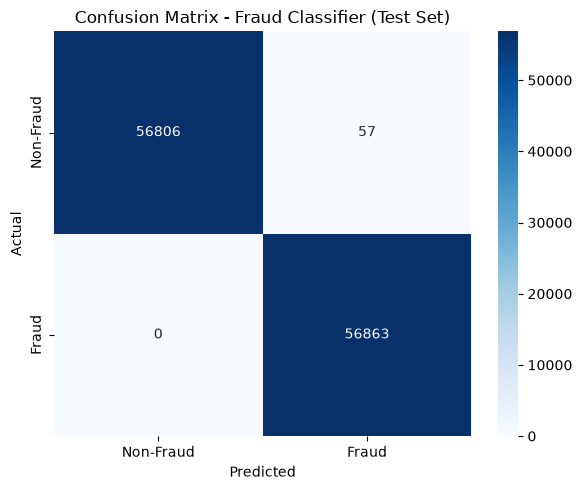

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fraud Classifier (Test Set)")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150)
plt.show()

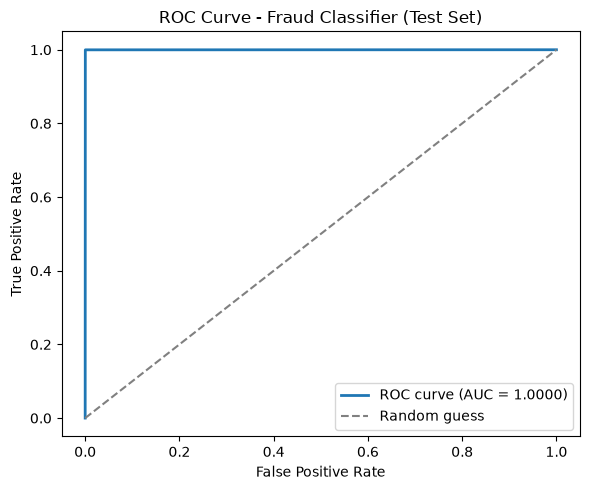

In [12]:
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Classifier (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/roc_curve.png", dpi=150)
plt.show()